# Name: Marielle Alexa Salvador
### Block: CAS-10-202A

# **LOMB SCARGLE PHASE FOLDING OF R AQUARII's DATA**

In [ ]:
#Install Modules
!pip install pandas
!pip install astropy
!pip install scipy
%matplotlib inline

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#Import Packages
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
from scipy.signal import lombscargle
import io
from astropy.time import Time

In [ ]:
#Upload the File Data
from google.colab import files
uploaded = files.upload()

Saving aavsodata_RAQR.txt to aavsodata_RAQR.txt


In [ ]:
#Read the Data
df = pd.read_csv(('aavsodata_RAQR.txt'), delimiter = '\t')
df

<ipython-input-10-4a90d11eddf1>:1: DtypeWarning: Columns (18,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(('aavsodata_RAQR.txt'), delimiter = '\t')


,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer,Code,Comment,Code(s),Comp,...,Observer.1,Affiliation,Measurement,Method,Grouping,Method.1,ADS,Reference,Digitizer,Credit
0,2394441.000,<10.2,Vis.,AFW,NaN,NaN,1900ANHAR-33-73.,ENTERED,BY,PKV.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2394464.000,7.9,Vis.,AFW,NaN,NaN,1900ANHAR-33-73.,ENTERED,BY,PKV.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2394464.000,7.8,Vis.,AFW,NaN,NaN,1900ANHAR-33-73.,ENTERED,BY,PKV.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2394465.000,7.8,Vis.,AFW,NaN,NaN,1900ANHAR-33-73.,ENTERED,BY,PKV.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2394471.000,7.8,Vis.,AFW,NaN,NaN,1900ANHAR-33-73.,ENTERED,BY,PKV.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25808,2459238.510,12.175,0.021,V,HMB,000-BCR-885,000-BCR-914,X19869ERA,STANDARD,MAG:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25809,2459238.510,12.754,0.02,B,HMB,000-BCR-885,000-BCR-914,X19869ERA,STANDARD,MAG:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25810,2459238.510,12.722,0.02,B,HMB,000-BCR-885,000-BCR-914,X19869ERA,STANDARD,MAG:,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25811,2459246.565,12,Vis.,CKB,Y,117,122,X15583FBH,VLB,Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Define Function and Remove the Term Value
def remove_symbol(value):

  if value[0]=='<':
    return value[1:]
  else:
    return value

df ['Magnitude'] = df['Magnitude'].apply(remove_symbol)

#Set Magnitude and JD as float

df ['Magnitude'] = df['Magnitude'].astype(float)
df ['JD'] = df['JD'].astype(float)

In [ ]:
#Convert JD into Calendar Date

date = Time(df['JD'], format='jd')
df['date'] = pd.to_datetime(date.iso)

/usr/local/lib/python3.10/dist-packages/erfa/core.py:154: ErfaWarning: ERFA function "d2dtf" yielded 7754 of "dubious year (Note 5)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


<Axes: xlabel='date', ylabel='Magnitude'>

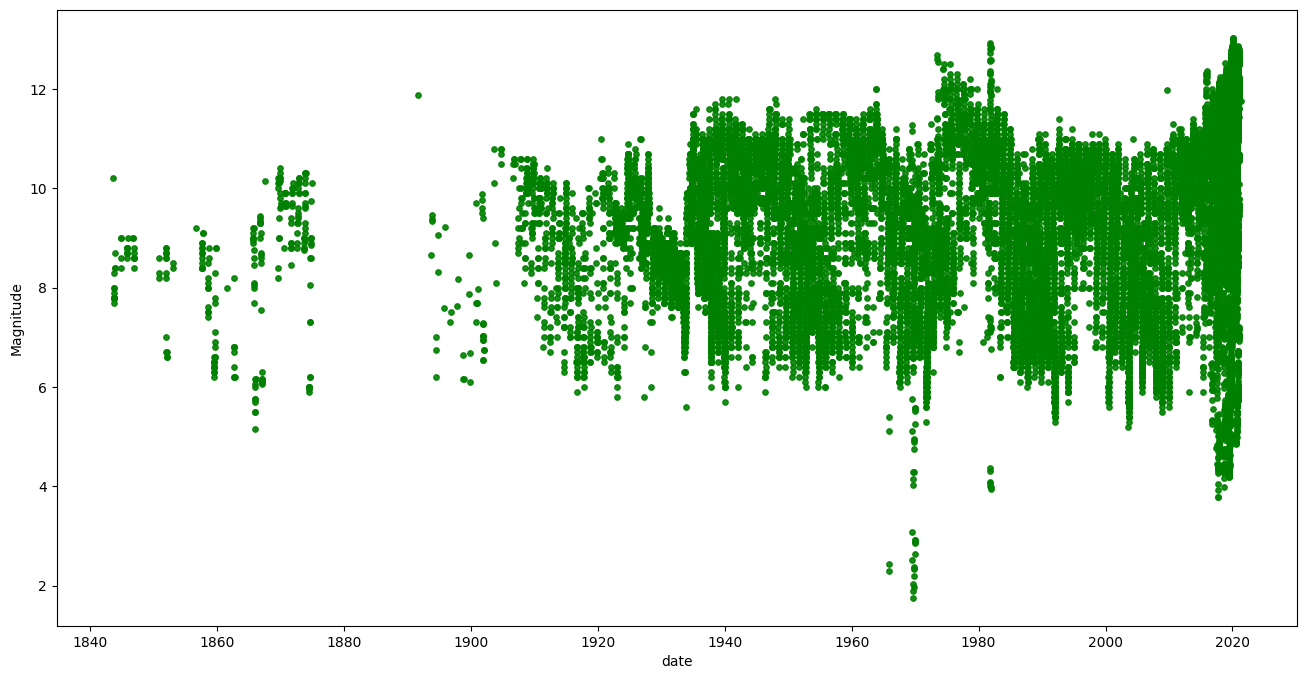

In [ ]:
#PLot the recent data
fig, ax = plt.subplots(1,1, figsize = (16, 8))

#Customize the data
df.plot.scatter(marker = 'o', color = 'green', s = 15, alpha = 0.9, x = 'date', y = 'Magnitude', ax = ax)

In [ ]:
#Input the starting date and end date based on what ma'am said

start_date = Time('2016-01-01 00:00:01')
end_date = Time('2018-01-01 00:00:01')

<Axes: xlabel='date', ylabel='Magnitude'>

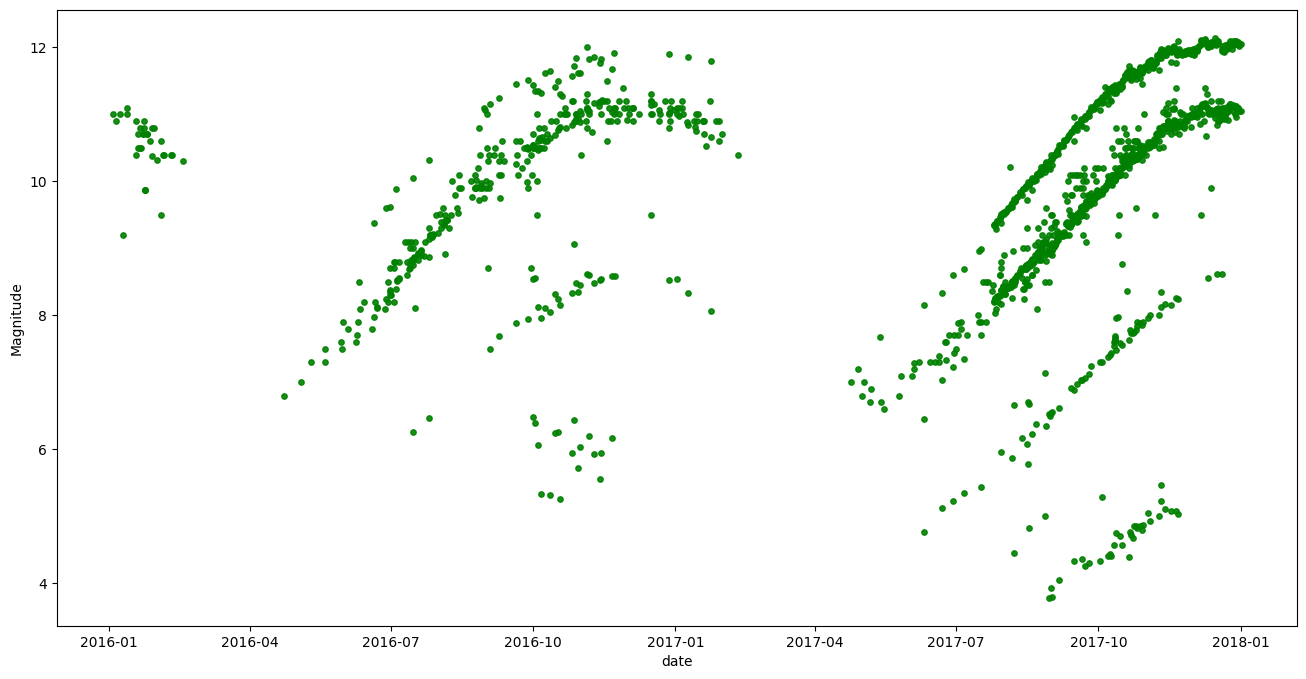

In [ ]:
#Choose recent data
recent_data = df[(date>start_date) & (date<end_date)]

fig, ax = plt.subplots(1,1, figsize =(16, 8))

#Plot the recent data

recent_data.plot.scatter(marker = 'o', color = 'g', s = 15, alpha = 0.9, x = 'date', y = 'Magnitude', ax = ax)

# **LOMB-SCARGLE PERIODOGRAM**

In [ ]:
#Compute the periodogram
lf = LombScargle(recent_data['JD'], recent_data['Magnitude'])

minimum_rotation_period = 300
maximum_rotation_period = 600

frequencies, powers = lf.autopower(minimum_frequency = 1.0 / maximum_rotation_period, maximum_frequency = 1.0 / minimum_rotation_period)

Text(0, 0.5, 'Lomb-Scargle Power')

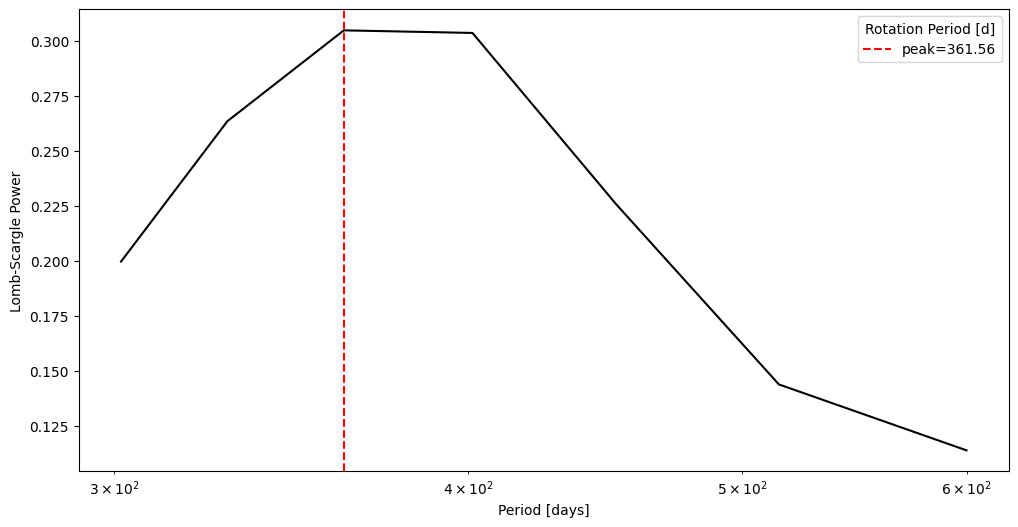

In [ ]:
#Convert frequency in period
periods = 1.0 / frequencies

import numpy as np

best_freq = frequencies[np.argmax(powers)]
best_period = 1.0 / best_freq

fig, ax = plt.subplots(1,1, figsize = (12, 6))

ax.plot(periods, powers, 'k-')
ax.axvline(best_period, 0, 1, ls = '--', c = 'r', label = f'peak={best_period:.2f}')
ax.legend(title = 'Rotation Period [d]')
ax.set_xscale('log')
ax.set_xlabel('Period [days]')
ax.set_ylabel('Lomb-Scargle Power')

# **PHASE-FOLDING OF A LIGHT CURVE**

In [ ]:
peak_period = 361.56

In [ ]:
data = np.genfromtxt('aavsodata_RAQR.txt', skip_header = 1, usecols = (0,1))
time = data[:, 0]
flux = data[:, 1]

In [ ]:
#Compute the phase value
phase = (time / peak_period) %1

# Sort indices based on the value of phase
sorted_indices = np.argsort(phase)

#Sort phase and flux values
phase_folded = phase[sorted_indices]
flux_folded = flux[sorted_indices]

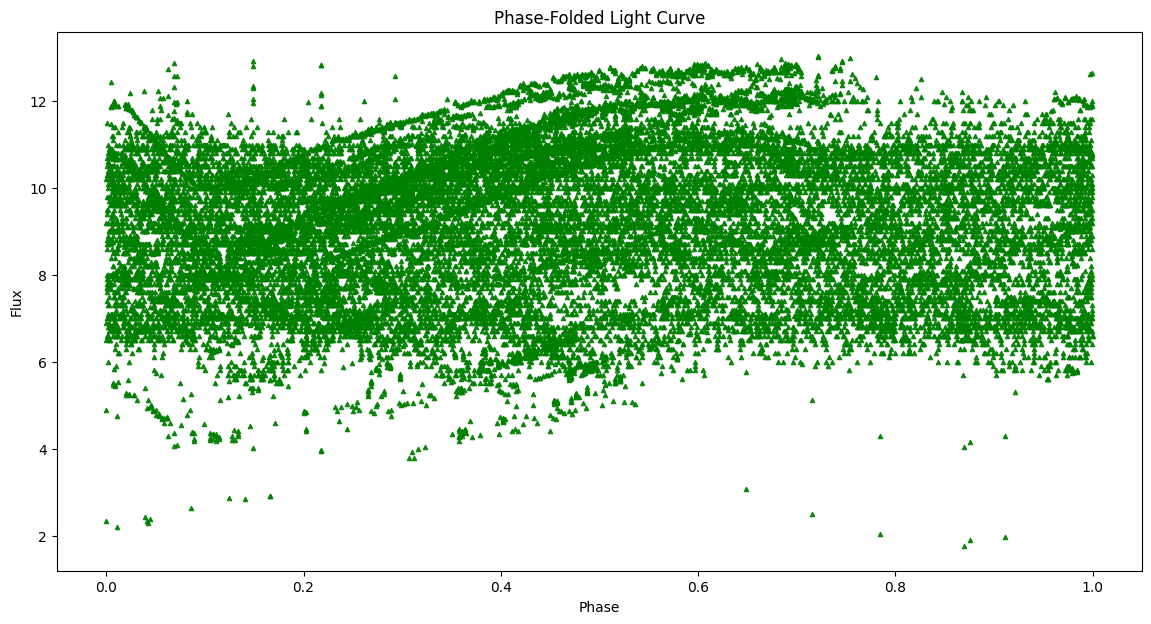

In [ ]:
#Plot the Phase-Folded Light Curve
fig, ax = plt.subplots(figsize = (14, 7))
plt.scatter(phase_folded, flux_folded, linewidth = 1, marker = '^', color = 'green', s = 9, alpha = 0.9)
plt.xlabel('Phase')
plt.ylabel('Flux')
plt.title('Phase-Folded Light Curve')
plt.show()